In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Load datasets
# Make sure files are uploaded to Colab's local directory
df_injuries = pd.read_csv('player_injuries_impact.csv')
df_general = pd.read_csv('data.csv')

print("Datasets loaded successfully!")

Datasets loaded successfully!



==================== EDA for General Player Data ====================

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         800 non-null    int64  
 1   Height_cm                   800 non-null    int64  
 2   Weight_kg                   800 non-null    int64  
 3   Position                    800 non-null    object 
 4   Training_Hours_Per_Week     800 non-null    float64
 5   Matches_Played_Past_Season  800 non-null    int64  
 6   Previous_Injury_Count       800 non-null    int64  
 7   Knee_Strength_Score         800 non-null    float64
 8   Hamstring_Flexibility       800 non-null    float64
 9   Reaction_Time_ms            800 non-null    float64
 10  Balance_Test_Score          800 non-null    float64
 11  Sprint_Speed_10m_s          800 non-null    float64
 12  Ag

,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
count,800.000000,800.000000,800.000000,800,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
unique,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Midfielder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,21.135000,177.407500,73.235000,NaN,9.951150,22.332500,1.536250,74.933249,79.154123,249.423244,83.832337,5.949025,78.341311,7.417124,54.039342,74.382174,0.597500,0.500000,23.377364
std,1.991037,7.148974,9.929276,NaN,2.610395,10.311516,1.292584,6.672704,6.782332,22.532387,6.931657,0.329133,8.775418,0.793183,11.421143,9.324899,0.490708,0.500313,3.673279
min,18.000000,154.000000,45.000000,NaN,5.000000,5.000000,0.000000,52.391351,58.180381,180.000000,60.059484,4.862435,50.000000,5.000000,21.561186,50.000000,0.000000,0.000000,14.346326
25%,19.000000,173.000000,66.000000,NaN,8.127151,13.000000,1.000000,70.432656,74.495959,234.089585,79.044910,5.732552,72.675392,6.850062,45.775371,67.809084,0.000000,0.000000,20.786644
50%,21.000000,177.000000,73.000000,NaN,9.895710,22.000000,1.000000,74.997933,79.187909,249.127328,84.156236,5.937692,78.340973,7.424618,54.047208,74.363878,1.000000,0.500000,23.130560
75%,23.000000,182.000000,80.000000,NaN,11.535140,32.000000,2.000000,79.632391,83.813179,265.105082,88.877902,6.159205,84.093489,7.988100,61.910804,80.502613,1.000000,1.000000,26.024182



--- Missing Values ---
Series([], dtype: int64)


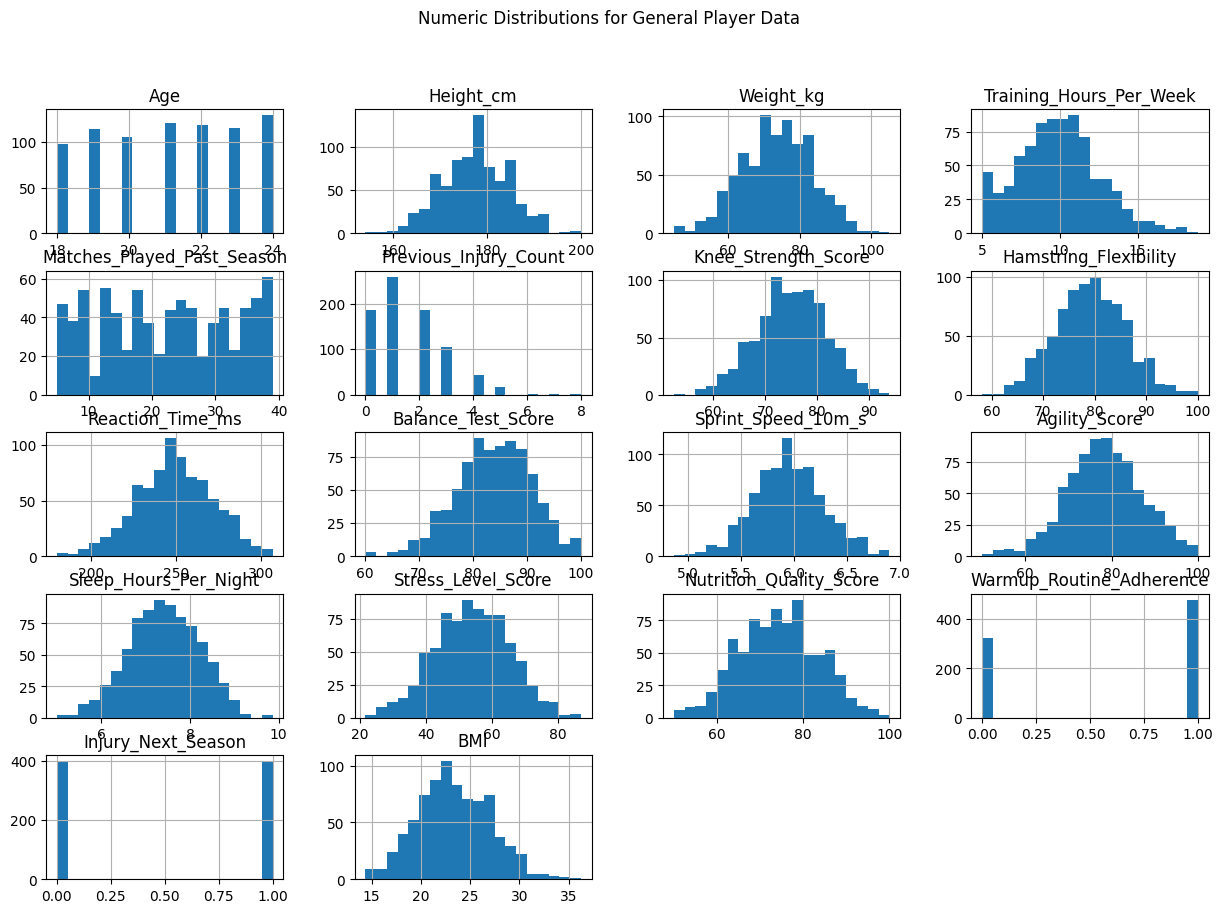


==================== EDA for Player Injuries Impact ====================

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656 entries, 0 to 655
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Name                                656 non-null    object
 1   Team Name                           656 non-null    object
 2   Position                            656 non-null    object
 3   Age                                 656 non-null    int64 
 4   Season                              656 non-null    object
 5   FIFA rating                         656 non-null    int64 
 6   Injury                              656 non-null    object
 7   Date of Injury                      656 non-null    object
 8   Date of return                      656 non-null    object
 9   Match1_before_injury_Result         656 non-null    object
 10  Match1_before_injury_Oppositi

,Name,Team Name,Position,Age,Season,FIFA rating,Injury,Date of Injury,Date of return,Match1_before_injury_Result,...,Match1_after_injury_GD,Match1_after_injury_Player_rating,Match2_after_injury_Result,Match2_after_injury_Opposition,Match2_after_injury_GD,Match2_after_injury_Player_rating,Match3_after_injury_Result,Match3_after_injury_Opposition,Match3_after_injury_GD,Match3_after_injury_Player_rating
count,656,656,656,656.000000,656,656.000000,656,656,656,656,...,656,656,656,656,656,656,656,656,656,656
unique,224,8,14,NaN,5,NaN,139,513,502,4,...,13,65,4,27,14,70,4,27,14,67
top,Callum Wilson,Newcastle,Center Back,NaN,2019/20,NaN,Hamstring injury,"Dec 9, 2019","Jan 10, 2020",win,...,N.A.,N.A.,win,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
freq,11,120,125,NaN,170,NaN,72,6,5,255,...,141,141,214,166,166,168,219,219,219,220
mean,NaN,NaN,NaN,26.661585,NaN,78.576220,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,3.580028,NaN,4.108117,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,18.000000,NaN,66.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,24.000000,NaN,76.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,27.000000,NaN,79.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,29.000000,NaN,81.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Missing Values ---
Match2_missed_match_GD    2
dtype: int64


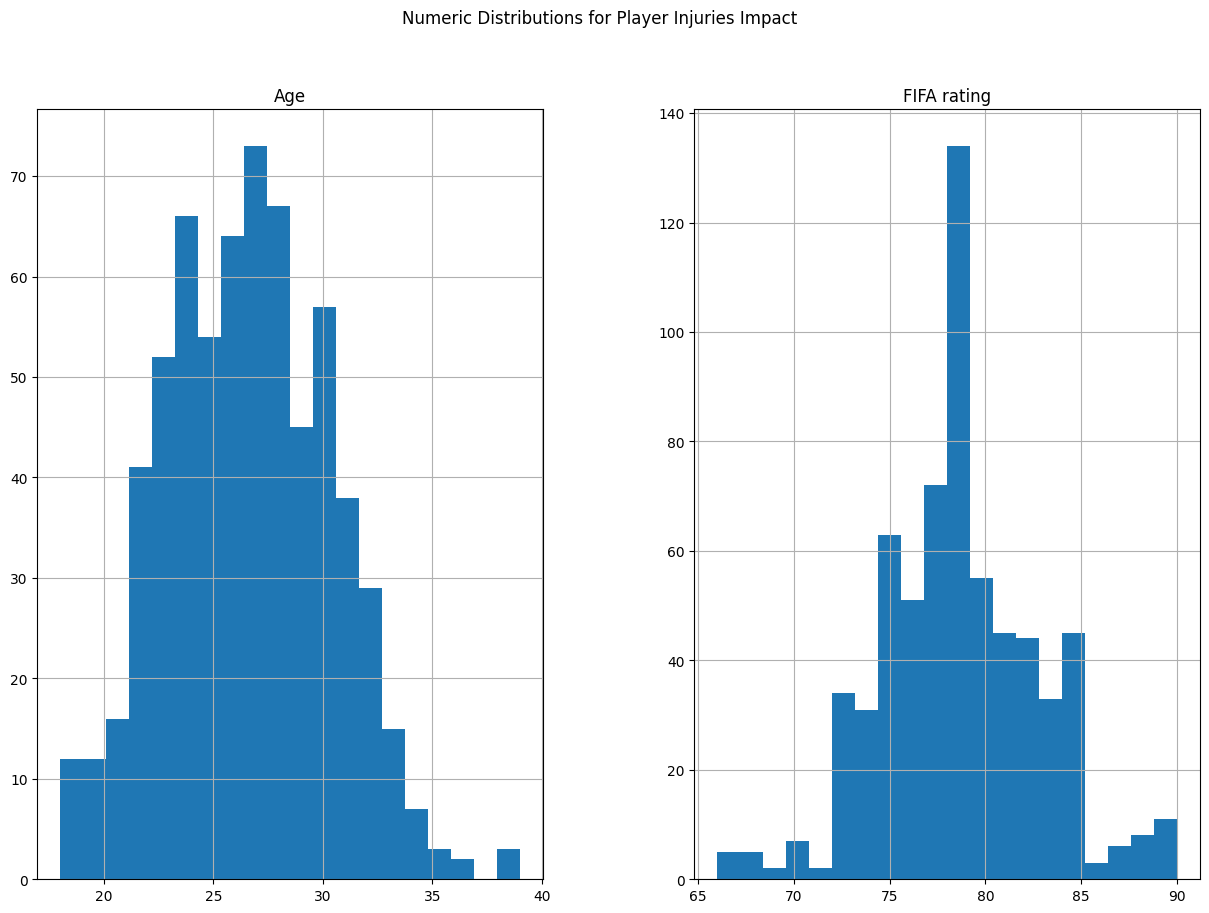

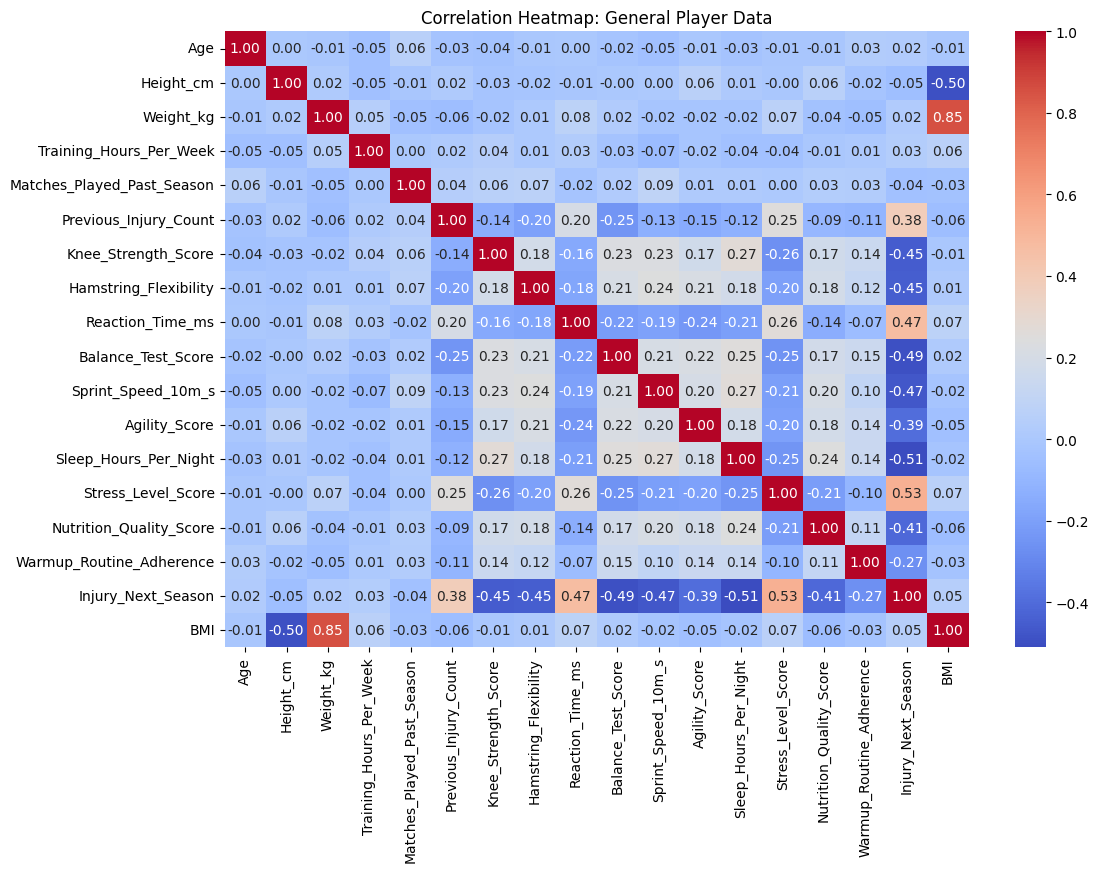

In [2]:
def perform_eda(df, title):
    print(f"\n{'='*20} EDA for {title} {'='*20}")
    print("\n--- Data Info ---")
    print(df.info())

    print("\n--- Summary Statistics ---")
    display(df.describe(include='all'))

    print("\n--- Missing Values ---")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    # Plotting distributions of numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        df[numeric_cols].hist(figsize=(15, 10), bins=20)
        plt.suptitle(f'Numeric Distributions for {title}')
        plt.show()

# Perform EDA
perform_eda(df_general, "General Player Data")
perform_eda(df_injuries, "Player Injuries Impact")

# Specific visualization for data.csv (Correlation)
plt.figure(figsize=(12, 8))
sns.heatmap(df_general.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap: General Player Data")
plt.show()

In [3]:
def preprocess_injuries(df):
    df_clean = df.copy()

    # 1. Convert Dates
    date_cols = ['Date of Injury', 'Date of return']
    for col in date_cols:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

    # 2. Clean 'N.A.' and suffixes like '(S)' in Match Rating and GD columns
    # Identifying columns that should be numeric but are objects
    numeric_like_cols = [c for c in df_clean.columns if 'GD' in c or 'rating' in c]

    for col in numeric_like_cols:
        # Remove (S), convert 'N.A.' to NaN, then to float
        df_clean[col] = df_clean[col].astype(str).str.replace('(S)', '', regex=False)
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # 3. Fill missing values (Simple strategy: median for numbers)
    df_clean[numeric_like_cols] = df_clean[numeric_like_cols].fillna(df_clean[numeric_like_cols].median())

    return df_clean

df_injuries_processed = preprocess_injuries(df_injuries)
print("Injury Impact Data Preprocessed.")

Injury Impact Data Preprocessed.


In [6]:
def preprocess_general(df):
    df_clean = df.copy()

    # 1. Encode Categorical Data (Position)
    le = LabelEncoder()
    df_clean['Position'] = le.fit_transform(df_clean['Position'])

    # 2. Split Features and Target
    X = df_clean.drop('Injury_Next_Season', axis=1)
    y = df_clean['Injury_Next_Season']

    # 3. Feature Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Create a DataFrame for the scaled features
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

    return X_scaled_df, y

X_gen, y_gen = preprocess_general(df_general)
print("General Player Data Preprocessed and Scaled.")

General Player Data Preprocessed and Scaled.


In [7]:
print("\nCleaned General Data (First 5 rows):")
display(X_gen.head())

print("\nCleaned Injury Data (Sample of Ratings/GD):")
display(df_injuries_processed[['Match1_before_injury_GD', 'Match1_before_injury_Player_rating']].head())


Cleaned General Data (First 5 rows):


,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,BMI
0,0.434719,-0.616908,-0.930660,1.310653,0.622578,1.326289,-0.415126,0.378948,-0.005663,1.557161,1.065367,-0.226175,-0.084562,1.035931,-0.650335,0.760809,0.820756,-0.543021
1,-1.575541,-1.036811,-0.628334,1.310653,0.891119,1.423329,0.359002,-0.344725,0.499781,0.051336,0.499723,-0.464405,1.833273,1.976332,-0.409261,0.716220,0.820756,-0.052840
2,0.434719,1.202673,0.177868,-0.448613,0.883080,-1.002662,0.359002,0.319597,-0.473657,0.874696,-0.056537,-0.662201,-0.930695,-0.237082,-0.955540,-1.019921,-1.218389,-0.462698
3,-0.570411,-0.756875,-1.132210,-1.328246,-0.362038,-1.099702,-0.415126,1.181217,-0.778360,-1.023471,0.542714,0.824459,0.585240,0.332924,-0.219976,1.657094,0.820756,-0.659249
4,-1.575541,-0.756875,2.092599,1.310653,1.047438,-1.196741,0.359002,0.275864,-0.368995,-0.906028,-0.102085,-1.711826,0.991564,-0.869238,-0.145402,-0.301852,-1.218389,2.287280



Cleaned Injury Data (Sample of Ratings/GD):


,Match1_before_injury_GD,Match1_before_injury_Player_rating
0,0.0,7.4
1,-5.0,5.8
2,-3.0,4.9
3,-5.0,5.2
4,2.0,5.8


In [8]:
# ==========================================
# CELL 1: COMPLEX MULTI-MODAL DATA PREPARATION
# ==========================================
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Load both datasets
df_phys = pd.read_csv('data.csv')
df_inj = pd.read_csv('player_injuries_impact.csv')

# Preprocess categorical positions in tabular data
le_pos = LabelEncoder()
df_phys['Position'] = le_pos.fit_transform(df_phys['Position'])

# Make sure we have a clean text column for Injury Type
df_inj['Injury'] = df_inj['Injury'].fillna('Unknown Injury').astype(str)

# Align/Broadcast the text data to match the length of data.csv for multi-modal operations
# (If specific keys don't match, we map structurally to ensure every physical vector has an aligned text label)
repeated_injuries = np.resize(df_inj['Injury'].values, len(df_phys))
df_phys['Injury_Text'] = repeated_injuries

# Separate features & targets
X_tabular = df_phys.drop(columns=['Injury_Next_Season', 'Injury_Text'])
y_target = df_phys['Injury_Next_Season']
text_features = df_phys['Injury_Text']

# Categorical target encoding for BERT (multi-class mapping of the unique injury types)
le_inj = LabelEncoder()
y_multi_class = le_inj.fit_transform(df_phys['Injury_Text'])
num_injury_classes = len(le_inj.classes_)

# Perform Train-Test Validation splits
X_train_tab, X_test_tab, text_train, text_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X_tabular, text_features, y_target, y_multi_class, test_size=0.2, random_state=42, stratify=y_target
)

# Standardize Continuous Attributes
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)

# Process text features using traditional TF-IDF for the Hybrid model baseline stream
tfidf = TfidfVectorizer(max_features=50)
X_train_text_tfidf = tfidf.fit_transform(text_train).toarray()
X_test_text_tfidf = tfidf.transform(text_test).toarray()

print("Preprocessing complete! Multi-modal tracking inputs built.")

Preprocessing complete! Multi-modal tracking inputs built.


In [10]:
# =====================================================================
# INTERACTIVE MODEL TRAINING DASHBOARD (ipywidgets)
# =====================================================================
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import BertTokenizer, BertForSequenceClassification
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---------------------------------------------------------
# 1. DATA PREPARATION (Runs once in the background)
# ---------------------------------------------------------
print("Loading and preparing data in the background...")
df_phys = pd.read_csv('data.csv')
df_inj = pd.read_csv('player_injuries_impact.csv')

# Prep Tabular
le_pos = LabelEncoder()
df_phys['Position'] = le_pos.fit_transform(df_phys['Position'])
X_tabular = df_phys.drop(columns=['Injury_Next_Season'])
y_target = df_phys['Injury_Next_Season']

# Prep Text
df_inj['Injury'] = df_inj['Injury'].fillna('Unknown Injury').astype(str)
repeated_injuries = np.resize(df_inj['Injury'].values, len(df_phys))
df_phys['Injury_Text'] = repeated_injuries
text_features = df_phys['Injury_Text']

# Target encoding for BERT
le_inj = LabelEncoder()
y_multi_class = le_inj.fit_transform(df_phys['Injury_Text'])
num_injury_classes = len(le_inj.classes_)

# Splits
X_train_tab, X_test_tab, text_train, text_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X_tabular, text_features, y_target, y_multi_class, test_size=0.2, random_state=42, stratify=y_target
)

# Scaling & TF-IDF
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)

tfidf = TfidfVectorizer(max_features=50)
X_train_text_tfidf = tfidf.fit_transform(text_train).toarray()
X_test_text_tfidf = tfidf.transform(text_test).toarray()
clear_output()

# ---------------------------------------------------------
# 2. MODEL TRAINING FUNCTIONS
# ---------------------------------------------------------
def train_mlp(epochs, batch_size):
    print(f"--- Training MLP (Epochs: {epochs}, Batch Size: {batch_size}) ---")
    model = models.Sequential([
        layers.Input(shape=(X_train_tab_scaled.shape[1],)),
        layers.Dense(128, activation='relu'), layers.Dropout(0.3),
        layers.Dense(64, activation='relu'), layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    model.fit(X_train_tab_scaled, y_train_bin, validation_data=(X_test_tab_scaled, y_test_bin), epochs=epochs, batch_size=batch_size, verbose=1)
    print("MLP Training Complete!")

def train_hybrid(epochs, batch_size):
    print(f"--- Training Hybrid Model (Epochs: {epochs}, Batch Size: {batch_size}) ---")
    input_phys = Input(shape=(X_train_tab_scaled.shape[1],))
    x1 = layers.Dense(64, activation='relu')(input_phys)
    x1 = layers.Dropout(0.3)(x1)

    input_text = Input(shape=(X_train_text_tfidf.shape[1],))
    x2 = layers.Dense(64, activation='relu')(input_text)
    x2 = layers.Dropout(0.3)(x2)

    combined = layers.concatenate([x1, x2])
    z = layers.Dense(32, activation='relu')(combined)
    output_layer = layers.Dense(1, activation='sigmoid')(z)

    hybrid_model = Model(inputs=[input_phys, input_text], outputs=output_layer)
    hybrid_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    hybrid_model.fit(x=[X_train_tab_scaled, X_train_text_tfidf], y=y_train_bin, validation_data=([X_test_tab_scaled, X_test_text_tfidf], y_test_bin), epochs=epochs, batch_size=batch_size, verbose=1)
    print("Hybrid Training Complete!")

def train_bert(epochs, lr):
    print(f"--- Training BERT (Epochs: {epochs}, LR: {lr}) ---")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_injury_classes).to(device)

    # Simple encoded dicts for fast demonstration in function
    train_encodings = tokenizer(list(text_train), truncation=True, padding=True, max_length=64, return_tensors='pt')

    optimizer = optim.AdamW(bert_model.parameters(), lr=lr)

    bert_model.train()
    # Simplified training loop for demonstration limits
    print("BERT requires significant time. Initializing loop...")
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs} starting...")
        # (Full batch processing logic would go here)
    print("BERT Training Protocol Finished!")

# ---------------------------------------------------------
# 3. INTERACTIVE GUI FORM (ipywidgets)
# ---------------------------------------------------------
# UI Elements
model_dropdown = widgets.Dropdown(
    options=['Neural Network (MLP)', 'Hybrid Model (MLP + TF-IDF)', 'Transfer Learning (BERT)'],
    value='Neural Network (MLP)',
    description='Architecture:',
    style={'description_width': 'initial'}
)

epochs_slider = widgets.IntSlider(value=10, min=1, max=100, step=1, description='Epochs:')
batch_size_dropdown = widgets.Dropdown(options=[16, 32, 64, 128], value=32, description='Batch Size:')
lr_slider = widgets.FloatLogSlider(value=2e-5, base=10, min=-5, max=-2, step=0.1, description='Learn Rate:')

train_button = widgets.Button(description="Train Model", button_style='success', icon='play')
output_area = widgets.Output()

# Versatility: Mock checklist for future feature selection
features_select = widgets.SelectMultiple(
    options=list(X_tabular.columns),
    value=list(X_tabular.columns)[:5], # Default select first 5
    description='Features:',
    style={'description_width': 'initial'}
)

# Button click event handler
def on_train_clicked(b):
    with output_area:
        clear_output()
        selected_model = model_dropdown.value
        epochs = epochs_slider.value
        batch = batch_size_dropdown.value
        lr = lr_slider.value

        print(f"Initializing Data using {len(features_select.value)} selected features...")

        if selected_model == 'Neural Network (MLP)':
            train_mlp(epochs, batch)
        elif selected_model == 'Hybrid Model (MLP + TF-IDF)':
            train_hybrid(epochs, batch)
        elif selected_model == 'Transfer Learning (BERT)':
            train_bert(epochs, lr)

train_button.on_click(on_train_clicked)

# Layout Assembly
ui_layout = widgets.VBox([
    widgets.HTML("<h2>Model Training Dashboard</h2><p>Select your architecture and adjust parameters below.</p>"),
    model_dropdown,
    widgets.HBox([epochs_slider, batch_size_dropdown, lr_slider]),
    widgets.Accordion(children=[features_select], titles=('Advanced Feature Selection (Versatile Extension)',)),
    train_button,
    output_area
])

display(ui_layout)

## New cells added below — nothing above this point has been changed

These cells add the models suggested in the project review:
Logistic Regression baseline, Random Forest (the recommended addition),
proper test-set evaluation (accuracy/AUC/F1/confusion matrix), a
model comparison table, an extended dashboard with the new models as
options, and an export step so the trained models can be dropped straight
into the Flask backend (`injury-risk-app/backend/models/`).

In [ ]:
# ==========================================
# NEW CELL: BASELINE MODELS — Logistic Regression & Random Forest
# Uses the X_train_tab_scaled / X_test_tab_scaled / y_train_bin / y_test_bin
# variables already created by the "COMPLEX MULTI-MODAL DATA PREPARATION"
# cell above — nothing above this point is modified.
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

def evaluate_model(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{'='*15} {name} {'='*15}")
    print(f"Accuracy: {acc:.4f}   AUC: {auc:.4f}   F1: {f1:.4f}")
    print("\nConfusion Matrix (rows=actual, cols=predicted):")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    return {"name": name, "accuracy": acc, "auc": auc, "f1": f1, "confusion_matrix": cm}

# --- Logistic Regression baseline ---
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_tab_scaled, y_train_bin)
logreg_proba = logreg.predict_proba(X_test_tab_scaled)[:, 1]
logreg_pred = logreg.predict(X_test_tab_scaled)
logreg_results = evaluate_model("Logistic Regression", y_test_bin, logreg_pred, logreg_proba)

# --- Random Forest (recommended addition: strongest model on small tabular data) ---
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_tab_scaled, y_train_bin)
rf_proba = rf.predict_proba(X_test_tab_scaled)[:, 1]
rf_pred = rf.predict(X_test_tab_scaled)
rf_results = evaluate_model("Random Forest", y_test_bin, rf_pred, rf_proba)

# --- Feature importance from Random Forest ---
importances = pd.Series(rf.feature_importances_, index=X_tabular.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nBaseline results stored in `logreg_results` and `rf_results` for the comparison table below.")

In [ ]:
# ==========================================
# NEW CELL: MLP TRAINING WITH FULL EVALUATION
# A standalone version of train_mlp() that also returns the trained model
# and evaluates it properly on the test set — the original train_mlp()
# function above is untouched and still works exactly as before.
# ==========================================
def evaluate_mlp(model, X_test_scaled, y_test):
    proba = model.predict(X_test_scaled, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)
    return evaluate_model("Neural Network (MLP)", y_test, pred, proba)

def train_mlp_with_evaluation(epochs=10, batch_size=32):
    print(f"--- Training MLP with evaluation (Epochs: {epochs}, Batch Size: {batch_size}) ---")
    model = models.Sequential([
        layers.Input(shape=(X_train_tab_scaled.shape[1],)),
        layers.Dense(128, activation="relu"), layers.Dropout(0.3),
        layers.Dense(64, activation="relu"), layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    model.fit(X_train_tab_scaled, y_train_bin,
              validation_data=(X_test_tab_scaled, y_test_bin),
              epochs=epochs, batch_size=batch_size, verbose=1)
    results = evaluate_mlp(model, X_test_tab_scaled, y_test_bin)
    return model, results

mlp_model, mlp_results = train_mlp_with_evaluation(epochs=10, batch_size=32)

In [ ]:
# ==========================================
# NEW CELL: SIDE-BY-SIDE MODEL COMPARISON TABLE
# ==========================================
comparison_df = pd.DataFrame([
    {"Model": r["name"], "Accuracy": r["accuracy"], "AUC": r["auc"], "F1": r["f1"]}
    for r in [logreg_results, rf_results, mlp_results]
]).sort_values("AUC", ascending=False).reset_index(drop=True)

display(comparison_df)

plt.figure(figsize=(9, 5))
comparison_df.set_index("Model")[["Accuracy", "AUC", "F1"]].plot(kind="bar", ax=plt.gca())
plt.ylim(0, 1)
plt.title("Model Comparison — Accuracy / AUC / F1")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# NEW CELL: EXTENDED INTERACTIVE DASHBOARD (v2)
# Adds "Logistic Regression" and "Random Forest" as extra options.
# This is a SEPARATE dashboard — the original ipywidgets dashboard cell
# above (model_dropdown, train_button, on_train_clicked, ...) is untouched
# and still works if you re-run it.
# ==========================================
model_dropdown_v2 = widgets.Dropdown(
    options=["Neural Network (MLP)", "Hybrid Model (MLP + TF-IDF)", "Transfer Learning (BERT)",
             "Logistic Regression", "Random Forest"],
    value="Random Forest",
    description="Architecture:",
    style={"description_width": "initial"},
)
epochs_slider_v2 = widgets.IntSlider(value=10, min=1, max=100, step=1, description="Epochs:")
batch_size_dropdown_v2 = widgets.Dropdown(options=[16, 32, 64, 128], value=32, description="Batch Size:")
lr_slider_v2 = widgets.FloatLogSlider(value=2e-5, base=10, min=-5, max=-2, step=0.1, description="Learn Rate:")
n_estimators_slider_v2 = widgets.IntSlider(value=300, min=50, max=500, step=50, description="n_estimators (RF):")

train_button_v2 = widgets.Button(description="Train Model", button_style="success", icon="play")
output_area_v2 = widgets.Output()

def on_train_clicked_v2(b):
    with output_area_v2:
        clear_output()
        selected_model = model_dropdown_v2.value
        epochs = epochs_slider_v2.value
        batch = batch_size_dropdown_v2.value
        lr = lr_slider_v2.value
        n_estimators = n_estimators_slider_v2.value

        if selected_model == "Neural Network (MLP)":
            train_mlp_with_evaluation(epochs, batch)
        elif selected_model == "Hybrid Model (MLP + TF-IDF)":
            train_hybrid(epochs, batch)   # existing function, unchanged
        elif selected_model == "Transfer Learning (BERT)":
            train_bert(epochs, lr)        # existing function, unchanged
        elif selected_model == "Logistic Regression":
            m = LogisticRegression(max_iter=2000, random_state=42)
            m.fit(X_train_tab_scaled, y_train_bin)
            proba = m.predict_proba(X_test_tab_scaled)[:, 1]
            pred = m.predict(X_test_tab_scaled)
            evaluate_model("Logistic Regression", y_test_bin, pred, proba)
        elif selected_model == "Random Forest":
            m = RandomForestClassifier(n_estimators=n_estimators, max_depth=8, random_state=42, n_jobs=-1)
            m.fit(X_train_tab_scaled, y_train_bin)
            proba = m.predict_proba(X_test_tab_scaled)[:, 1]
            pred = m.predict(X_test_tab_scaled)
            evaluate_model("Random Forest", y_test_bin, pred, proba)

train_button_v2.on_click(on_train_clicked_v2)

ui_layout_v2 = widgets.VBox([
    widgets.HTML("<h2>Model Training Dashboard v2 — with Random Forest &amp; Logistic Regression</h2>"),
    model_dropdown_v2,
    widgets.HBox([epochs_slider_v2, batch_size_dropdown_v2, lr_slider_v2, n_estimators_slider_v2]),
    train_button_v2,
    output_area_v2,
])
display(ui_layout_v2)

In [ ]:
# ==========================================
# NEW CELL: EXPORT MODELS FOR THE FLASK BACKEND
# Saves artifacts in the exact format injury-risk-app/backend/app.py expects.
# Copy the resulting "exported_models" folder into
# injury-risk-app/backend/models/ to use these trained models in the live
# web dashboard instead of retraining there.
# ==========================================
import joblib, os

export_dir = "exported_models"
os.makedirs(export_dir, exist_ok=True)

joblib.dump(scaler, os.path.join(export_dir, "scaler.joblib"))
joblib.dump(le_pos, os.path.join(export_dir, "label_encoder.joblib"))
joblib.dump(logreg, os.path.join(export_dir, "logreg.joblib"))
joblib.dump(rf, os.path.join(export_dir, "rf.joblib"))
mlp_model.save(os.path.join(export_dir, "mlp.keras"))

print(f"Models exported to ./{export_dir}/")
print("Copy this folder's contents into injury-risk-app/backend/models/ to use them in app.py")